(Set-ExecutionPolicy -Scope Process -ExecutionPolicy RemoteSigned) ; (& c:\Users\owner\.vscode\code\.venv\Scripts\Activate.ps1)

PassengerId - 各乗客に割り当てられた一意のID。各IDは「gggg_pp」という形式をとります。ここで、ggggは乗客が同行するグループを示し、ppはそのグループ内での順位を表します。グループのメンバーは多くの場合家族ですが、必ずしもそうとは限りません。
HomePlanet - 乗客が出発した惑星。通常は、その乗客の永住惑星です。
CryoSleep - 乗客が航海期間中、仮死状態に入ることを選択したかどうかを示します。仮死状態にある乗客は、自身のキャビンに留まらなければなりません。
Cabin - 乗客が滞在しているキャビン番号。「デッキ/番号/サイド」という形式で表され、サイドは「P」（左舷）または「S」（右舷）のいずれかです。
Destination - 乗客が下船する惑星。
Age - 乗客の年齢。
VIP - 乗客が航海中に特別なVIPサービスの料金を支払っているかどうか。
RomService, FoodCourt, ShoppingMall, Spa, VRDeck - 宇宙船タイタニック号のさまざまな豪華施設ごとに、乗客が請求された金額。
Name - 乗客の氏名（名と姓）。
Transported - 乗客が別の次元へ転送されたかどうか。これが予測対象となる列です。

In [1]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split

train = pd.read_csv('./spaceship-titanic/train.csv')
test = pd.read_csv('./spaceship-titanic/test.csv')

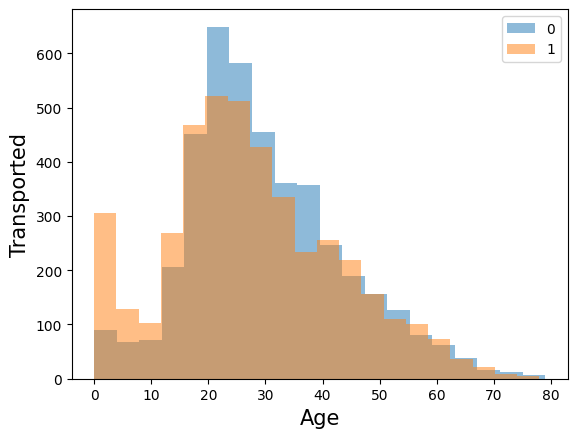

In [2]:
from itertools import product

#中盤くらいはFalse，若い人たちはTrue寄りの傾向

plt.hist(train.loc[train['Transported'] == False, "Age"].dropna(), bins=20, alpha=0.5, label='0')
plt.hist(train.loc[train['Transported'] == True, "Age"].dropna(), bins=20, alpha=0.5, label='1')
plt.xlabel(f"Age", fontsize=15)
plt.ylabel(f"Transported", fontsize=15)
plt.legend()

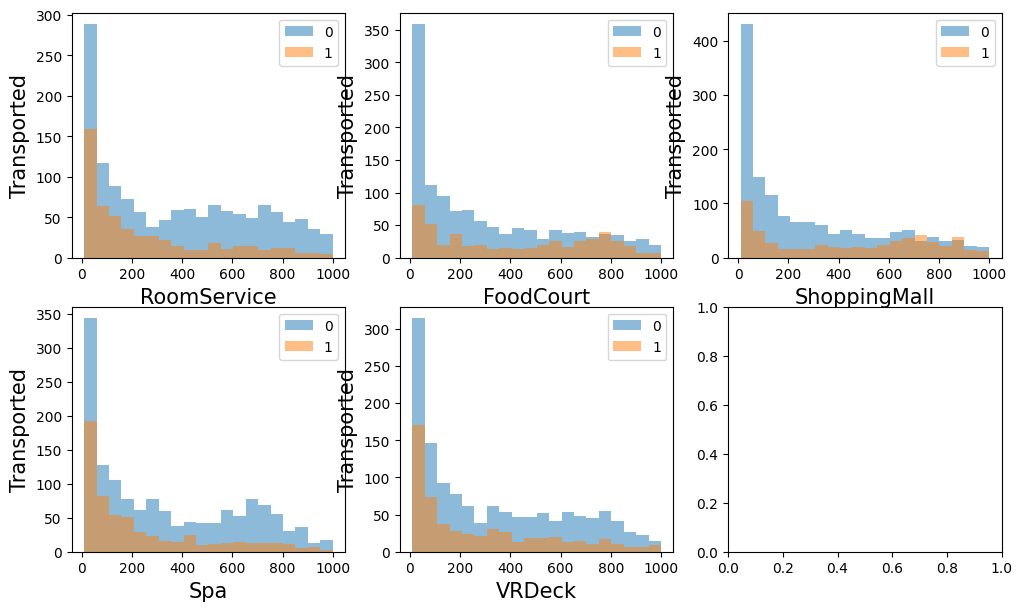

In [3]:

fig, ax = plt.subplots(2, 3, figsize=(12, 7))
columns_list = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

#全体的に使っていないやつは1(Transported)，少しでも使っている奴は0(No)よりの傾向

for column, (i, j) in zip(columns_list, product(range(2), range(3))):
    
    ax[i, j].hist(train.loc[train['Transported'] == False, column].dropna(), range=(10, 1000), bins=20, alpha=0.5, label='0')
    ax[i, j].hist(train.loc[train['Transported'] == True, column].dropna(), range=(10, 1000), bins=20, alpha=0.5, label='1')
    ax[i, j].set_xlabel(f"{column}", fontsize=15)
    ax[i, j].set_ylabel(f"Transported", fontsize=15)
    ax[i, j].legend()

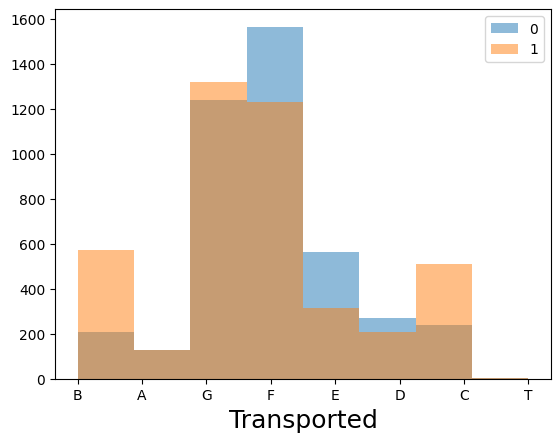

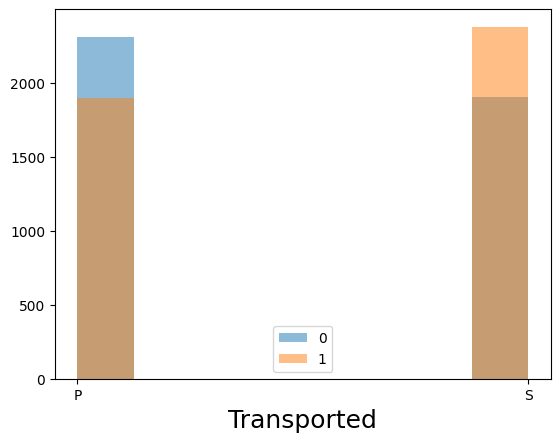

In [32]:
train['Deck'] = train['Cabin'].str.split('/').str[0]
train['SidePS'] = train['Cabin'].str.split('/').str[2]

for column in ["Deck", "SidePS"]:
    plt.hist(train.loc[train['Transported'] == False, column].dropna(), bins=8, alpha=0.5, label='0')
    plt.hist(train.loc[train['Transported'] == True, column].dropna(), bins=8, alpha=0.5, label='1')
    plt.xlabel(f"{column}", fontsize=18)
    plt.xlabel(f"Transported", fontsize=18)
    plt.legend()
    plt.show()

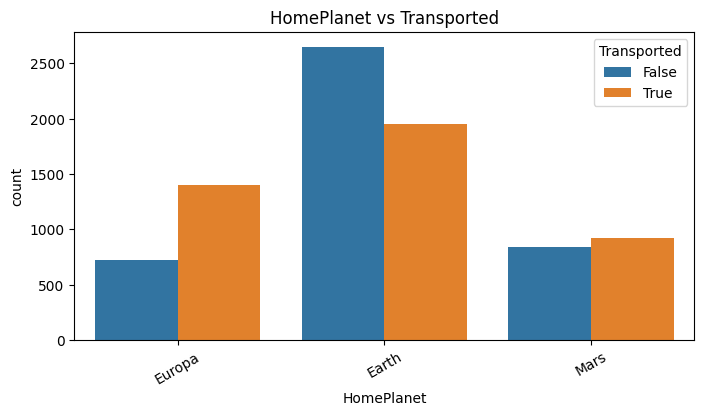

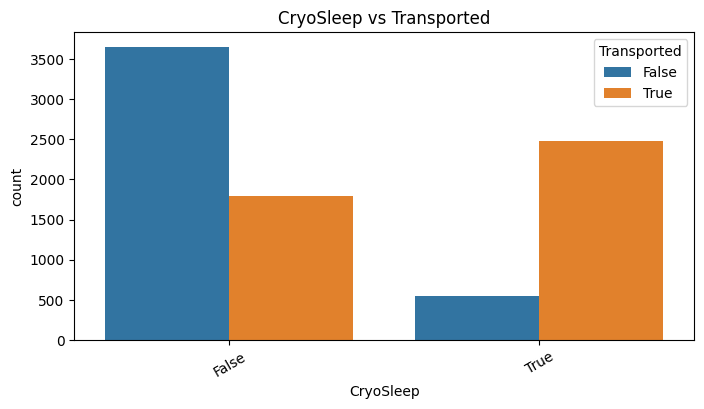

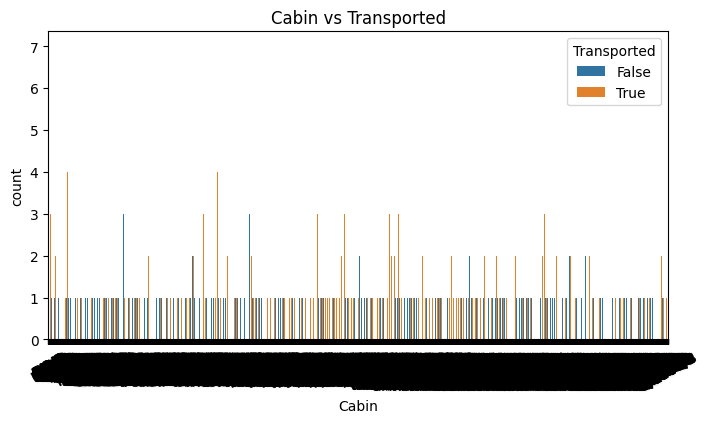

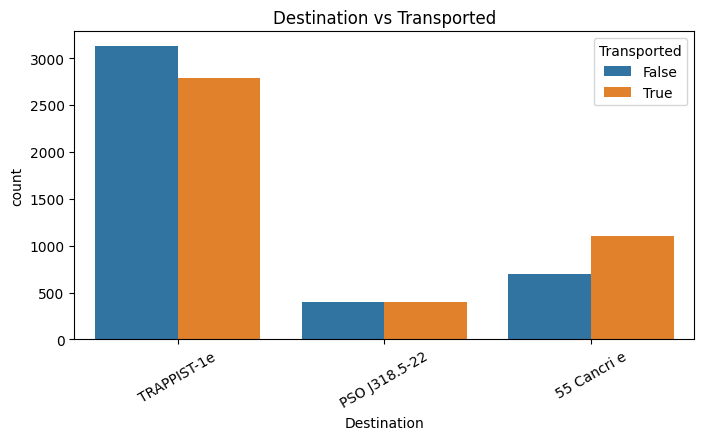

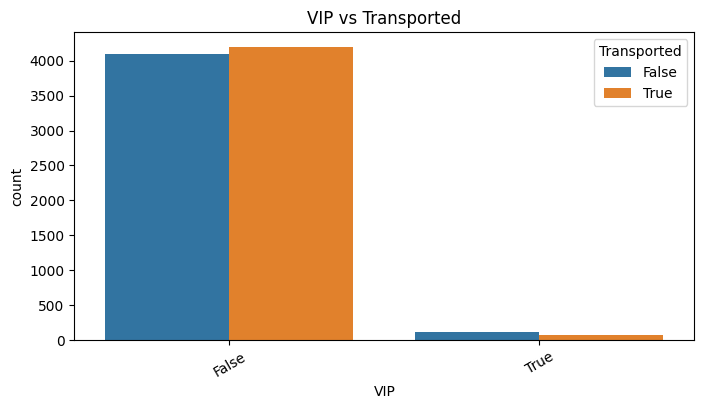

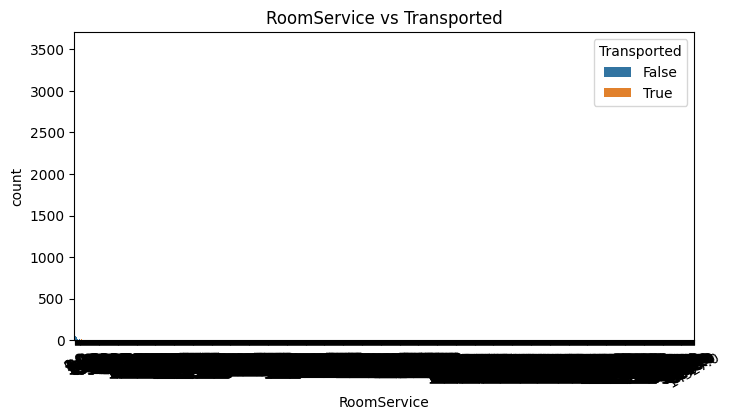

In [2]:


for column in train.columns.to_list():
    if column not in ('Transported', "PassengerId", "Name", "Age", "RomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"):
        plt.figure(figsize=(8, 4))
        sns.countplot(x=column, data=train, hue='Transported')
        plt.title(f'{column} vs Transported')
        plt.xticks(rotation=30)
        plt.show()


In [17]:
train = pd.read_csv('./spaceship-titanic/train.csv')
test = pd.read_csv('./spaceship-titanic/test.csv')

train.info()
# train.describe()
train.isnull().sum()

train_y = train['Transported']
train_X = train.drop(columns='Transported')
print(train_X.isnull().sum())

data = pd.concat([train_X, test])
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomS

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines


(array([320., 179.,  92., 127., 229., 293., 625., 881., 583., 835., 526.,
        615., 525., 349., 476., 376., 243., 274., 229., 111., 196.,  94.,
        116.,  84.,  52.,  32.,  22.,  11.,  11.,   8.]),
 array([ 0.        ,  2.63333333,  5.26666667,  7.9       , 10.53333333,
        13.16666667, 15.8       , 18.43333333, 21.06666667, 23.7       ,
        26.33333333, 28.96666667, 31.6       , 34.23333333, 36.86666667,
        39.5       , 42.13333333, 44.76666667, 47.4       , 50.03333333,
        52.66666667, 55.3       , 57.93333333, 60.56666667, 63.2       ,
        65.83333333, 68.46666667, 71.1       , 73.73333333, 76.36666667,
        79.        ]),
 <BarContainer object of 30 artists>)

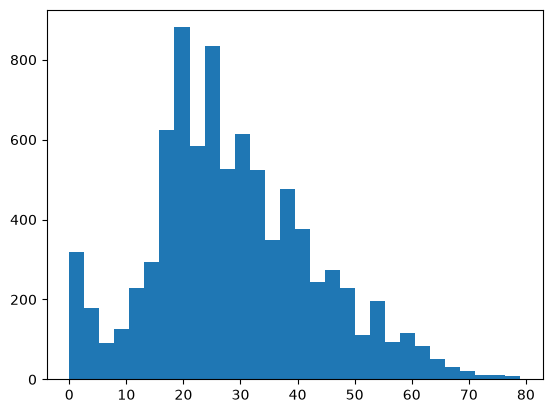

In [9]:
plt.hist(data.iloc[:len(train)]['Age'], bins=30)